In [17]:
# 06 - Reporte de señal de inversión
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Auto-detección de entorno: Colab o local
IS_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IS_COLAB = True
except Exception:
    IS_COLAB = False

if IS_COLAB:
    drive.mount('/content/drive')
    PROJECT_ROOT = Path('/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2')
else:
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name.lower() == 'notebooks':
        PROJECT_ROOT = PROJECT_ROOT.parent

REPORTS = PROJECT_ROOT / 'reports' / 'backtest'
MODELS = PROJECT_ROOT / 'models'
FIGURES = PROJECT_ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

def investment_score_to_label(score: float) -> str:
    if score >= 0.70:
        return 'muy_aconsejable'
    if score >= 0.55:
        return 'aconsejable'
    if score >= 0.45:
        return 'mantener_observar'
    if score >= 0.30:
        return 'riesgoso'
    return 'no_aconsejable'

print('IS_COLAB:', IS_COLAB)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('REPORTS:', REPORTS)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IS_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2
REPORTS: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest


In [18]:
# Cargar predicciones del modelo
pred_path = REPORTS / 'lstm_test_predictions_24h.csv'
if not pred_path.exists():
    raise FileNotFoundError(f'No existe {pred_path}. Ejecuta primero el notebook 05.')

pred = pd.read_csv(pred_path)
pred['timestamp'] = pd.to_datetime(pred['timestamp'], utc=True, errors='coerce')
pred = pred.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

print('Filas predicciones:', len(pred))
pred.head(3)

Filas predicciones: 136


,timestamp,y_true_ret_24h,y_pred_ret_24h,y_true_direction,y_pred_direction
0,2026-03-04 14:00:00+00:00,0.014620,-0.006755,1,0
1,2026-03-04 15:00:00+00:00,-0.025438,-0.007361,0,0
2,2026-03-04 16:00:00+00:00,-0.027802,-0.009044,0,0


In [19]:
# Construir score de inversión a partir del retorno predicho
# Escalado robusto del retorno predicho a [0,1] vía sigmoide
scale = pred['y_pred_ret_24h'].std()
if pd.isna(scale) or scale == 0:
    scale = 0.01

pred['investment_score'] = 1.0 / (1.0 + np.exp(-(pred['y_pred_ret_24h'] / scale)))
pred['investment_label'] = pred['investment_score'].apply(investment_score_to_label)

# Señal operativa binaria (larga si score>=0.55)
pred['signal_long'] = (pred['investment_score'] >= 0.55).astype(int)
pred['strategy_ret'] = pred['signal_long'] * pred['y_true_ret_24h']
pred['buy_hold_ret'] = pred['y_true_ret_24h']

pred['cum_strategy'] = (1 + pred['strategy_ret']).cumprod() - 1
pred['cum_buy_hold'] = (1 + pred['buy_hold_ret']).cumprod() - 1

pred[['timestamp', 'investment_score', 'investment_label', 'signal_long']].tail(5)

,timestamp,investment_score,investment_label,signal_long
131,2026-03-10 01:00:00+00:00,0.708972,muy_aconsejable,1
132,2026-03-10 02:00:00+00:00,0.714710,muy_aconsejable,1
133,2026-03-10 03:00:00+00:00,0.705604,muy_aconsejable,1
134,2026-03-10 04:00:00+00:00,0.701842,muy_aconsejable,1
135,2026-03-10 05:00:00+00:00,0.686007,aconsejable,1


In [20]:
# Métricas de señal y resumen
direction_acc = (pred['y_pred_direction'] == pred['y_true_direction']).mean()
hit_rate_when_long = (pred.loc[pred['signal_long'] == 1, 'y_true_ret_24h'] > 0).mean()
avg_ret_when_long = pred.loc[pred['signal_long'] == 1, 'y_true_ret_24h'].mean()
coverage_long = pred['signal_long'].mean()

summary = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'n_samples': int(len(pred)),
    'directional_accuracy': float(direction_acc),
    'long_signal_coverage': float(coverage_long),
    'hit_rate_when_long': float(hit_rate_when_long) if pd.notna(hit_rate_when_long) else None,
    'avg_return_when_long': float(avg_ret_when_long) if pd.notna(avg_ret_when_long) else None,
    'final_cum_strategy': float(pred['cum_strategy'].iloc[-1]),
    'final_cum_buy_hold': float(pred['cum_buy_hold'].iloc[-1]),
    'label_distribution': pred['investment_label'].value_counts(dropna=False).to_dict(),
}

summary

{'generated_at_utc': '2026-03-11T18:43:55.218521+00:00',
 'n_samples': 136,
 'directional_accuracy': 0.7941176470588235,
 'long_signal_coverage': 0.5147058823529411,
 'hit_rate_when_long': 0.7,
 'avg_return_when_long': 0.013771492733124321,
 'final_cum_strategy': 1.5683594086418924,
 'final_cum_buy_hold': -0.5629261998821957,
 'label_distribution': {'no_aconsejable': 51,
  'aconsejable': 40,
  'muy_aconsejable': 30,
  'mantener_observar': 10,
  'riesgoso': 5}}

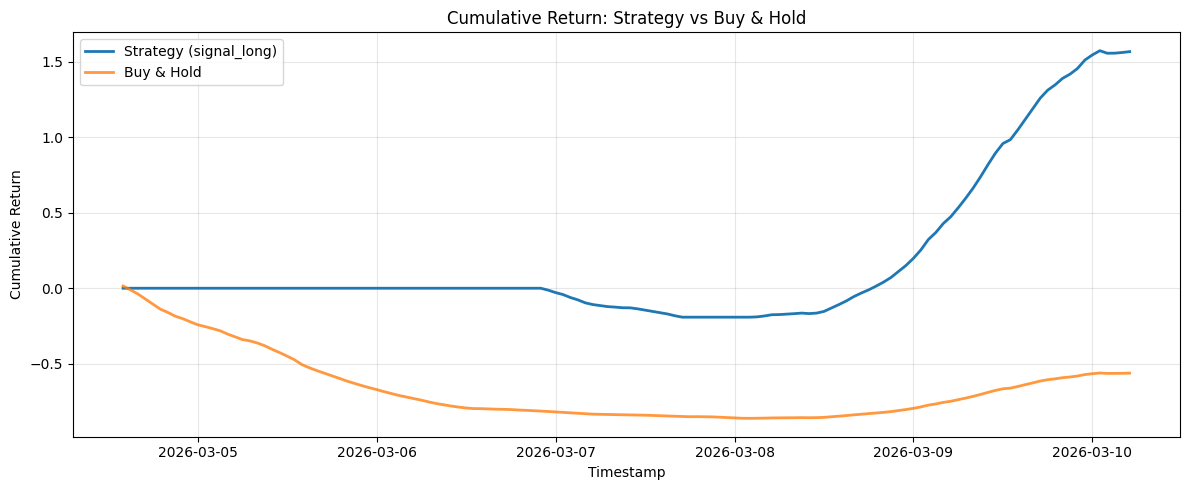

Figura guardada en: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/strategy_vs_buyhold.png


In [21]:
# Visualización rápida
plt.figure(figsize=(12, 5))
plt.plot(pred['timestamp'], pred['cum_strategy'], label='Strategy (signal_long)', linewidth=2)
plt.plot(pred['timestamp'], pred['cum_buy_hold'], label='Buy & Hold', linewidth=2, alpha=0.8)
plt.title('Cumulative Return: Strategy vs Buy & Hold')
plt.xlabel('Timestamp')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(alpha=0.3)
plot_path = FIGURES / 'strategy_vs_buyhold.png'
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.show()

print('Figura guardada en:', plot_path)

In [22]:
# Guardar reporte final
out_pred = REPORTS / 'investment_signal_report_24h.csv'
out_json = REPORTS / 'investment_signal_summary_24h.json'
pred.to_csv(out_pred, index=False)
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print('Reporte tabular:', out_pred)
print('Resumen JSON:', out_json)
pd.DataFrame([summary])

Reporte tabular: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest/investment_signal_report_24h.csv
Resumen JSON: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest/investment_signal_summary_24h.json


,generated_at_utc,n_samples,directional_accuracy,long_signal_coverage,hit_rate_when_long,avg_return_when_long,final_cum_strategy,final_cum_buy_hold,label_distribution
0,2026-03-11T18:43:55.218521+00:00,136,0.794118,0.514706,0.7,0.013771,1.568359,-0.562926,"{'no_aconsejable': 51, 'aconsejable': 40, 'muy..."


In [23]:
# Reporte avanzado de desempeño
periods_per_year = 24 * 365  # datos horarios

# Drawdown
equity = 1 + pred['cum_strategy']
running_max = equity.cummax()
drawdown = (equity / running_max) - 1
max_drawdown = drawdown.min()

# Métricas de retornos
mean_ret = pred['strategy_ret'].mean()
std_ret = pred['strategy_ret'].std(ddof=0)
downside_std = pred.loc[pred['strategy_ret'] < 0, 'strategy_ret'].std(ddof=0)
ann_return = (1 + mean_ret) ** periods_per_year - 1 if pd.notna(mean_ret) else np.nan
ann_vol = std_ret * np.sqrt(periods_per_year) if pd.notna(std_ret) else np.nan
sharpe = (mean_ret / std_ret) * np.sqrt(periods_per_year) if std_ret and std_ret > 0 else np.nan
sortino = (mean_ret / downside_std) * np.sqrt(periods_per_year) if downside_std and downside_std > 0 else np.nan

# Matriz de confusión de dirección
cm = confusion_matrix(pred['y_true_direction'], pred['y_pred_direction'], labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['true_down(0)', 'true_up(1)'], columns=['pred_down(0)', 'pred_up(1)'])

class_report = classification_report(
    pred['y_true_direction'],
    pred['y_pred_direction'],
    output_dict=True,
    zero_division=0,
 )
class_report_df = pd.DataFrame(class_report).transpose()

summary_advanced = {
    'max_drawdown': float(max_drawdown),
    'annualized_return_est': float(ann_return) if pd.notna(ann_return) else None,
    'annualized_volatility_est': float(ann_vol) if pd.notna(ann_vol) else None,
    'sharpe_est': float(sharpe) if pd.notna(sharpe) else None,
    'sortino_est': float(sortino) if pd.notna(sortino) else None,
}

summary_advanced

{'max_drawdown': -0.1918821210966225,
 'annualized_return_est': 7.4408548689324e+26,
 'annualized_volatility_est': 1.5134712529992833,
 'sharpe_est': 41.02702997971213,
 'sortino_est': 125.23812254709324}

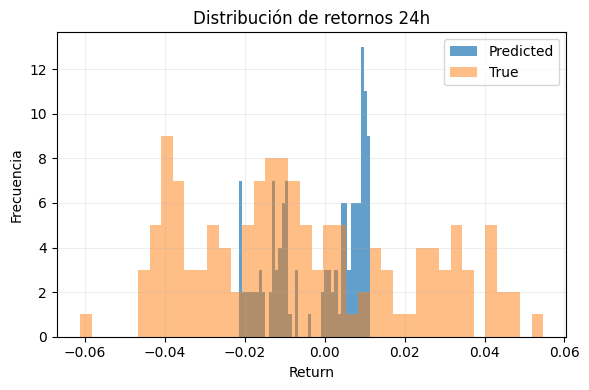

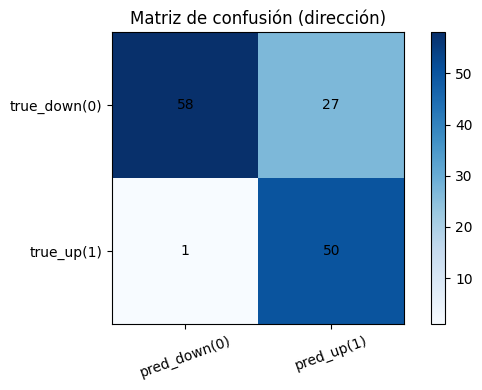

Figura histograma: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/returns_distribution_24h.png
Figura confusión: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/confusion_matrix_direction.png


In [24]:
# Visualizaciones adicionales
fig1 = plt.figure(figsize=(6, 4))
plt.hist(pred['y_pred_ret_24h'], bins=40, alpha=0.7, label='Predicted', color='tab:blue')
plt.hist(pred['y_true_ret_24h'], bins=40, alpha=0.5, label='True', color='tab:orange')
plt.title('Distribución de retornos 24h')
plt.xlabel('Return')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.2)
hist_path = FIGURES / 'returns_distribution_24h.png'
plt.tight_layout()
plt.savefig(hist_path, dpi=150)
plt.show()

fig2 = plt.figure(figsize=(6, 4))
plt.imshow(cm_df.values, cmap='Blues')
plt.xticks([0, 1], cm_df.columns, rotation=20)
plt.yticks([0, 1], cm_df.index)
for (i, j), v in np.ndenumerate(cm_df.values):
    plt.text(j, i, str(v), ha='center', va='center')
plt.title('Matriz de confusión (dirección)')
plt.colorbar()
cm_path = FIGURES / 'confusion_matrix_direction.png'
plt.tight_layout()
plt.savefig(cm_path, dpi=150)
plt.show()

print('Figura histograma:', hist_path)
print('Figura confusión:', cm_path)

In [25]:
# Guardar reportes avanzados
summary_full = {**summary, **summary_advanced}

cm_out = REPORTS / 'confusion_matrix_direction.csv'
class_out = REPORTS / 'classification_report_direction.csv'
summary_out = REPORTS / 'investment_signal_summary_advanced_24h.json'

cm_df.to_csv(cm_out, index=True)
class_report_df.to_csv(class_out, index=True)
with open(summary_out, 'w', encoding='utf-8') as f:
    json.dump(summary_full, f, ensure_ascii=False, indent=2)

print('Matriz confusión:', cm_out)
print('Classification report:', class_out)
print('Resumen avanzado:', summary_out)
pd.DataFrame([summary_full])

Matriz confusión: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest/confusion_matrix_direction.csv
Classification report: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest/classification_report_direction.csv
Resumen avanzado: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest/investment_signal_summary_advanced_24h.json


,generated_at_utc,n_samples,directional_accuracy,long_signal_coverage,hit_rate_when_long,avg_return_when_long,final_cum_strategy,final_cum_buy_hold,label_distribution,max_drawdown,annualized_return_est,annualized_volatility_est,sharpe_est,sortino_est
0,2026-03-11T18:43:55.218521+00:00,136,0.794118,0.514706,0.7,0.013771,1.568359,-0.562926,"{'no_aconsejable': 51, 'aconsejable': 40, 'muy...",-0.191882,7.440855e+26,1.513471,41.02703,125.238123


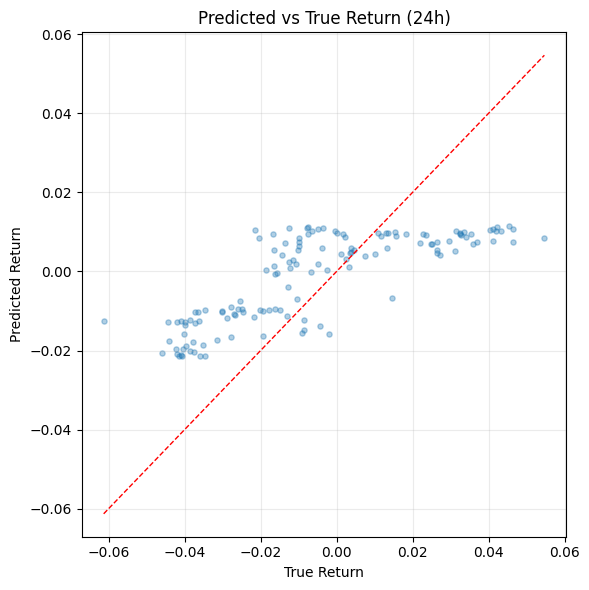

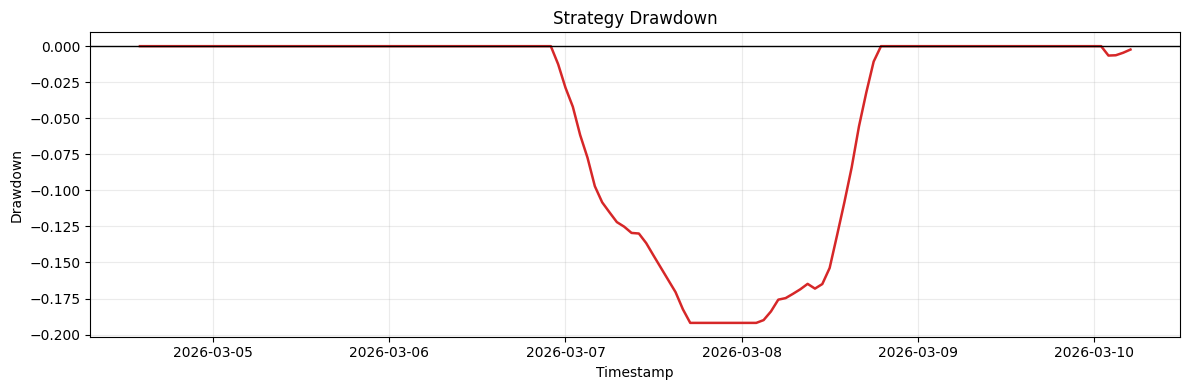

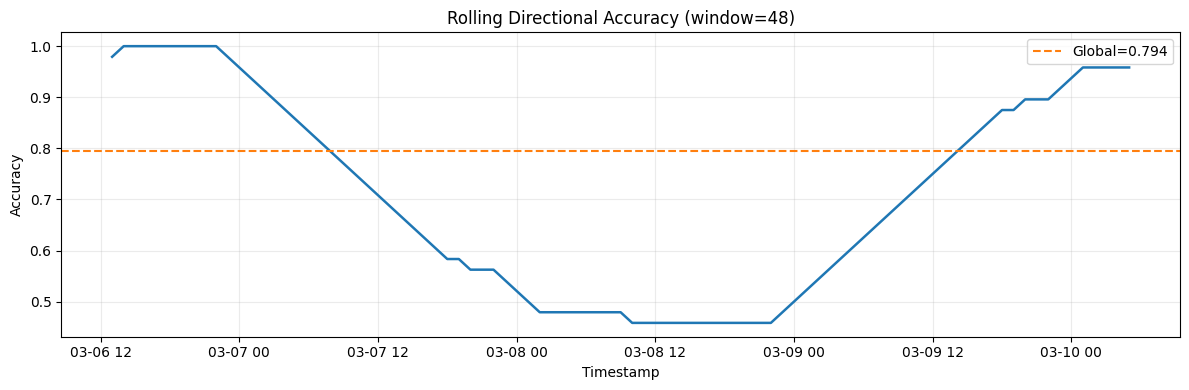

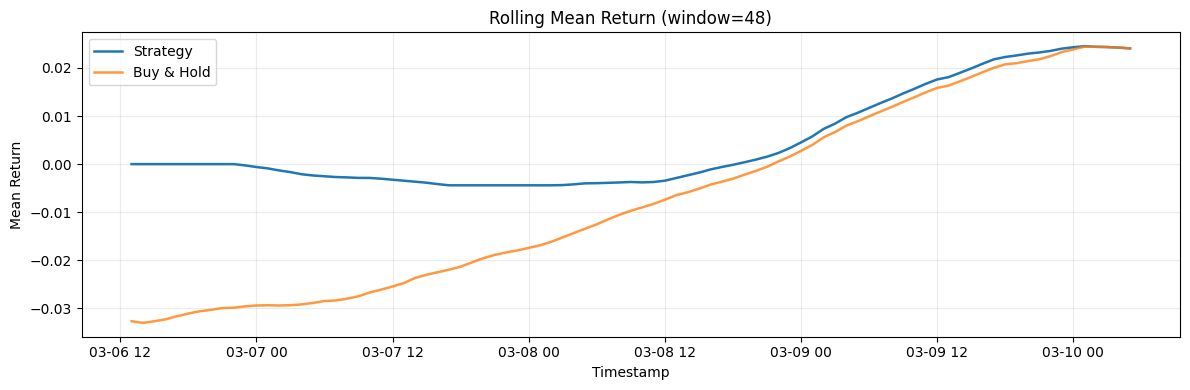

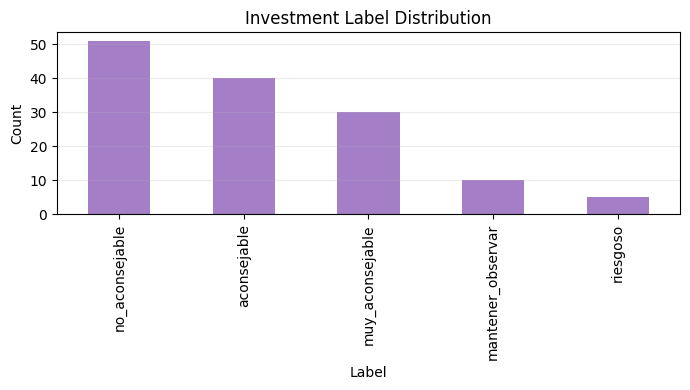

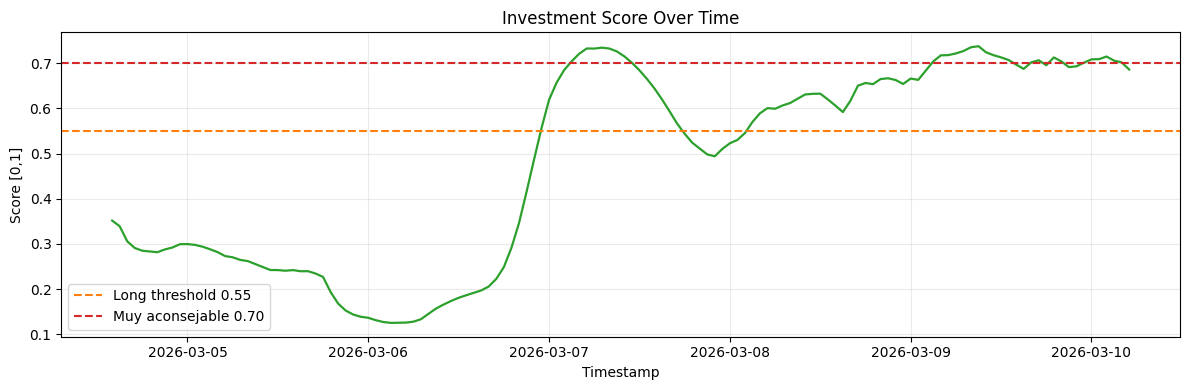

Total figuras nuevas: 6
/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/pred_vs_true_scatter_24h.png
/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/strategy_drawdown.png
/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/rolling_directional_accuracy_48.png
/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/rolling_mean_return_48.png
/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/investment_label_distribution.png
/content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/figures/investment_score_timeseries.png


In [26]:
# Galería completa de figuras para reports/figures
fig_paths = []

# 1) Predicho vs Real (retorno 24h)
plt.figure(figsize=(6, 6))
plt.scatter(pred['y_true_ret_24h'], pred['y_pred_ret_24h'], alpha=0.35, s=14)
mn = min(pred['y_true_ret_24h'].min(), pred['y_pred_ret_24h'].min())
mx = max(pred['y_true_ret_24h'].max(), pred['y_pred_ret_24h'].max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1)
plt.title('Predicted vs True Return (24h)')
plt.xlabel('True Return')
plt.ylabel('Predicted Return')
plt.grid(alpha=0.25)
p = FIGURES / 'pred_vs_true_scatter_24h.png'
plt.tight_layout(); plt.savefig(p, dpi=150); plt.show()
fig_paths.append(str(p))

# 2) Drawdown de estrategia
plt.figure(figsize=(12, 4))
plt.plot(pred['timestamp'], drawdown, color='tab:red', linewidth=1.8)
plt.axhline(0, color='black', linewidth=1)
plt.title('Strategy Drawdown')
plt.xlabel('Timestamp')
plt.ylabel('Drawdown')
plt.grid(alpha=0.25)
p = FIGURES / 'strategy_drawdown.png'
plt.tight_layout(); plt.savefig(p, dpi=150); plt.show()
fig_paths.append(str(p))

# 3) Rolling directional accuracy (ventana 48)
rolling_acc = (pred['y_pred_direction'] == pred['y_true_direction']).astype(int).rolling(48).mean()
plt.figure(figsize=(12, 4))
plt.plot(pred['timestamp'], rolling_acc, linewidth=1.8)
plt.axhline(direction_acc, linestyle='--', color='tab:orange', label=f'Global={direction_acc:.3f}')
plt.title('Rolling Directional Accuracy (window=48)')
plt.xlabel('Timestamp')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.25)
p = FIGURES / 'rolling_directional_accuracy_48.png'
plt.tight_layout(); plt.savefig(p, dpi=150); plt.show()
fig_paths.append(str(p))

# 4) Rolling mean return strategy vs buy&hold
roll_strategy = pred['strategy_ret'].rolling(48).mean()
roll_bh = pred['buy_hold_ret'].rolling(48).mean()
plt.figure(figsize=(12, 4))
plt.plot(pred['timestamp'], roll_strategy, label='Strategy', linewidth=1.8)
plt.plot(pred['timestamp'], roll_bh, label='Buy & Hold', linewidth=1.8, alpha=0.8)
plt.title('Rolling Mean Return (window=48)')
plt.xlabel('Timestamp')
plt.ylabel('Mean Return')
plt.legend()
plt.grid(alpha=0.25)
p = FIGURES / 'rolling_mean_return_48.png'
plt.tight_layout(); plt.savefig(p, dpi=150); plt.show()
fig_paths.append(str(p))

# 5) Distribución de etiquetas de inversión
label_counts = pred['investment_label'].value_counts()
plt.figure(figsize=(7, 4))
label_counts.plot(kind='bar', color='tab:purple', alpha=0.85)
plt.title('Investment Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.25)
p = FIGURES / 'investment_label_distribution.png'
plt.tight_layout(); plt.savefig(p, dpi=150); plt.show()
fig_paths.append(str(p))

# 6) Evolución de investment_score
plt.figure(figsize=(12, 4))
plt.plot(pred['timestamp'], pred['investment_score'], linewidth=1.6, color='tab:green')
plt.axhline(0.55, linestyle='--', color='tab:orange', label='Long threshold 0.55')
plt.axhline(0.70, linestyle='--', color='tab:red', label='Muy aconsejable 0.70')
plt.title('Investment Score Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Score [0,1]')
plt.legend()
plt.grid(alpha=0.25)
p = FIGURES / 'investment_score_timeseries.png'
plt.tight_layout(); plt.savefig(p, dpi=150); plt.show()
fig_paths.append(str(p))

print('Total figuras nuevas:', len(fig_paths))
for fp in fig_paths:
    print(fp)

In [27]:
# Inventario final de figuras generadas
all_figs = sorted([p.name for p in FIGURES.glob('*.png')])
manifest_path = REPORTS / 'figures_manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump({'generated_at_utc': datetime.now(timezone.utc).isoformat(), 'figures': all_figs}, f, ensure_ascii=False, indent=2)

print('Total figuras en reports/figures:', len(all_figs))
for name in all_figs:
    print('-', name)
print('Manifest:', manifest_path)

Total figuras en reports/figures: 9
- confusion_matrix_direction.png
- investment_label_distribution.png
- investment_score_timeseries.png
- pred_vs_true_scatter_24h.png
- returns_distribution_24h.png
- rolling_directional_accuracy_48.png
- rolling_mean_return_48.png
- strategy_drawdown.png
- strategy_vs_buyhold.png
Manifest: /content/drive/MyDrive/01. USFQ/01. Maestría IA/12. Trabajo de Titulación/05. V2/reports/backtest/figures_manifest.json
